----- Comparison for PEHE (Variant 1) -----
Model              BCF           XMVBCF             wsBCF
   1k 10.380 +/- 2.937 11.006 +/- 3.318  10.540 +/- 2.992
 0.5k 10.495 +/- 2.868 10.635 +/- 2.687  11.119 +/- 3.258
0.25k 10.508 +/- 2.831 10.884 +/- 3.023  12.531 +/- 4.143
 0.1k 10.621 +/- 2.813 10.679 +/- 2.756  17.961 +/- 8.271
0.05k 10.749 +/- 3.000 10.950 +/- 2.748 19.846 +/- 11.039




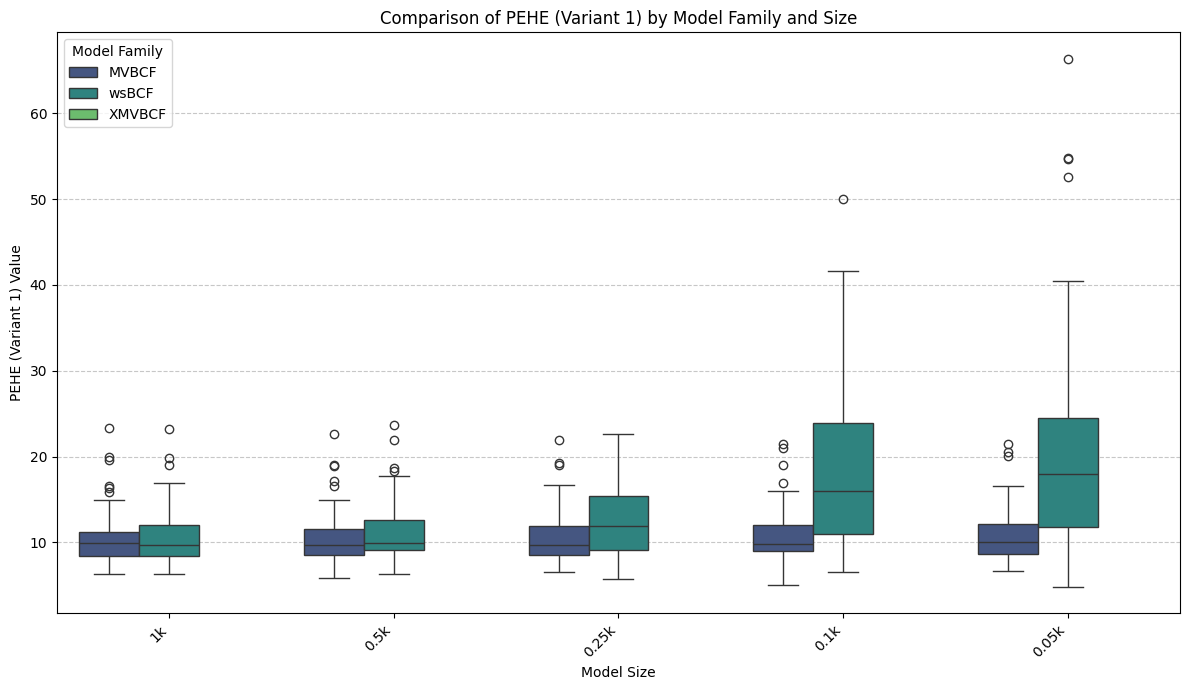

----- Comparison for PEHE (Variant 2) -----
Model              BCF           XMVBCF             wsBCF
   1k 10.540 +/- 2.727 10.703 +/- 2.378  10.635 +/- 2.962
 0.5k 10.598 +/- 2.870 10.680 +/- 2.578  11.259 +/- 2.981
0.25k 10.613 +/- 2.768 10.747 +/- 2.730  12.786 +/- 4.189
 0.1k 10.862 +/- 2.717 10.346 +/- 2.326  17.361 +/- 8.275
0.05k 11.170 +/- 3.134 10.655 +/- 2.484 19.878 +/- 11.379




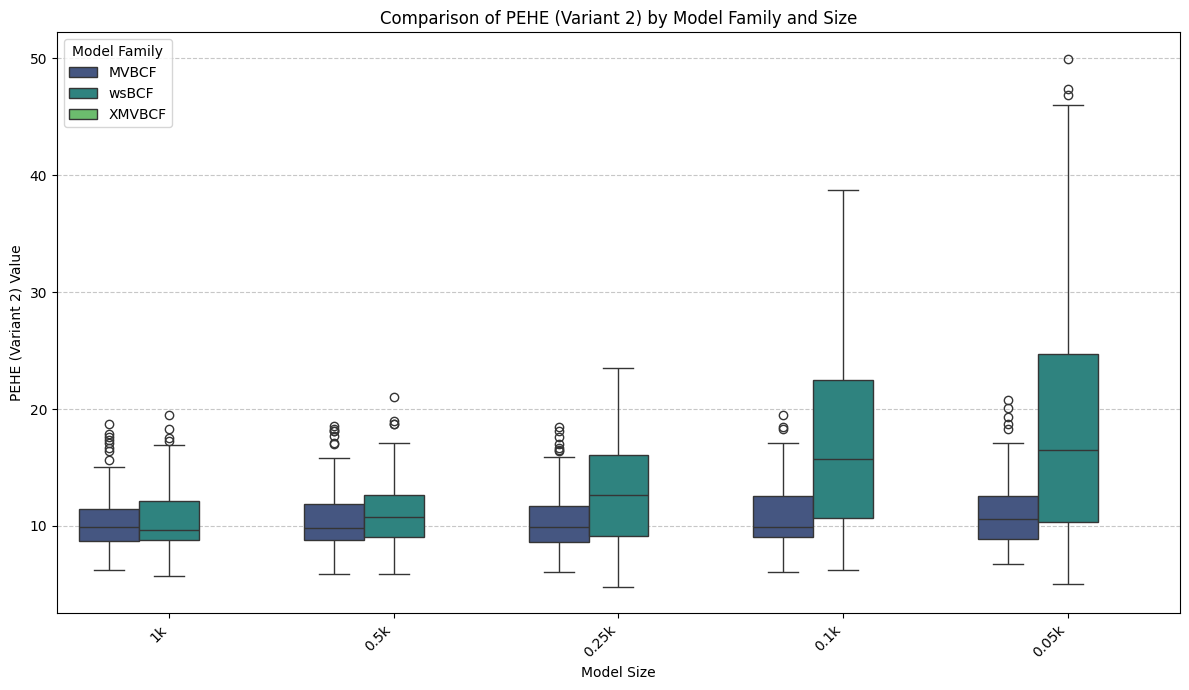

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.967 +/- 0.058 0.967 +/- 0.057 0.980 +/- 0.048
 0.5k 0.962 +/- 0.068 0.971 +/- 0.040 0.983 +/- 0.060
0.25k 0.958 +/- 0.062 0.970 +/- 0.047 0.983 +/- 0.062
 0.1k 0.945 +/- 0.077 0.968 +/- 0.049 0.911 +/- 0.190
0.05k 0.928 +/- 0.085 0.967 +/- 0.048 0.805 +/- 0.293




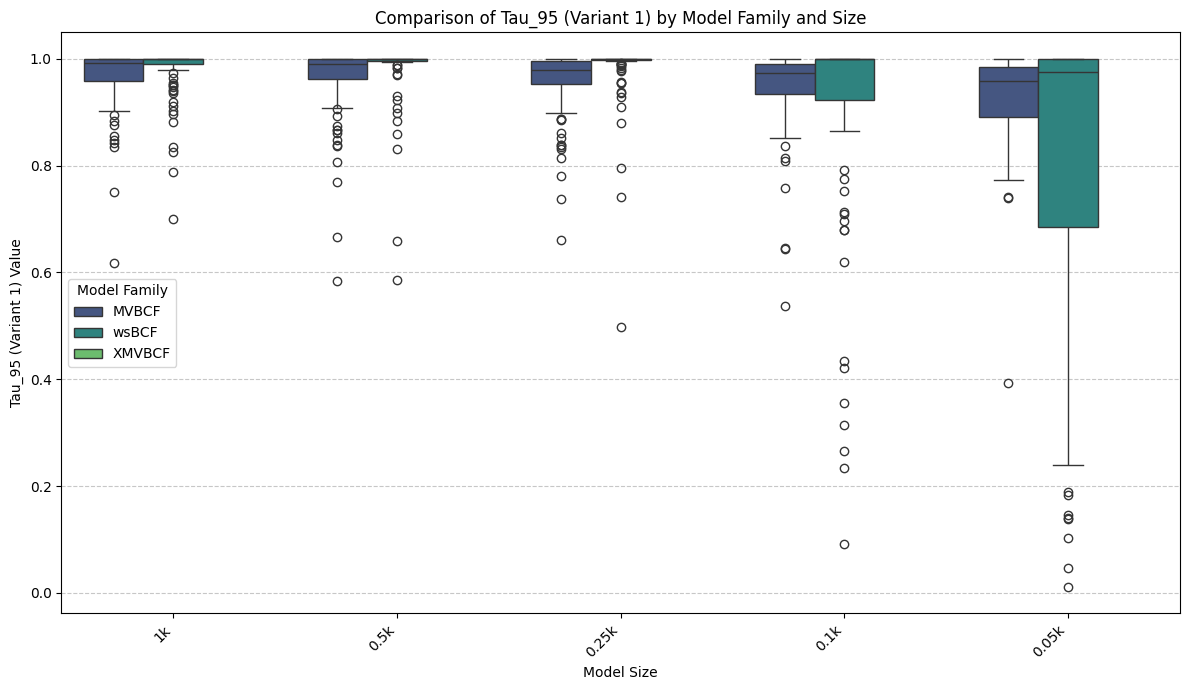

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.961 +/- 0.072 0.966 +/- 0.036 0.980 +/- 0.058
 0.5k 0.956 +/- 0.078 0.966 +/- 0.043 0.988 +/- 0.040
0.25k 0.955 +/- 0.072 0.966 +/- 0.043 0.987 +/- 0.047
 0.1k 0.939 +/- 0.078 0.972 +/- 0.035 0.923 +/- 0.181
0.05k 0.912 +/- 0.111 0.964 +/- 0.040 0.793 +/- 0.298




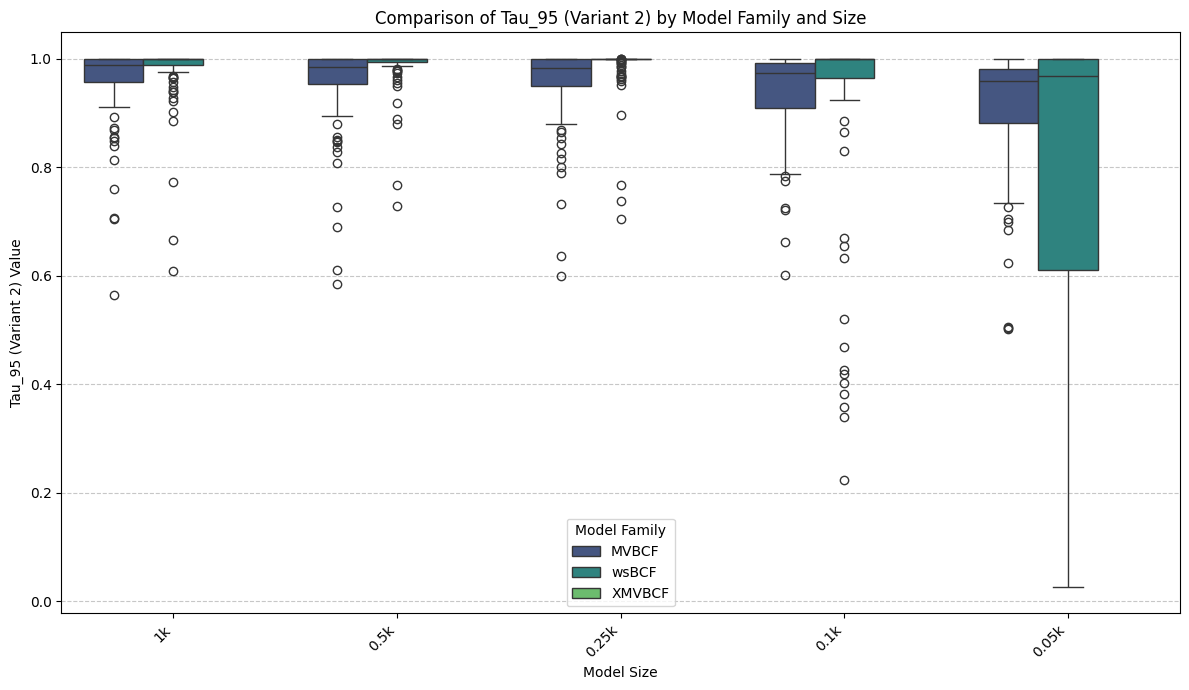

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF           XMVBCF             wsBCF
   1k 47.182 +/- 7.188 54.770 +/- 4.234 58.096 +/- 11.726
 0.5k 46.890 +/- 7.044 55.609 +/- 4.454 72.012 +/- 19.104
0.25k 46.058 +/- 7.620 55.215 +/- 4.606 87.430 +/- 30.805
 0.1k 44.712 +/- 7.831 55.384 +/- 4.513 81.224 +/- 32.100
0.05k 43.126 +/- 7.711 55.222 +/- 4.121 79.517 +/- 36.826




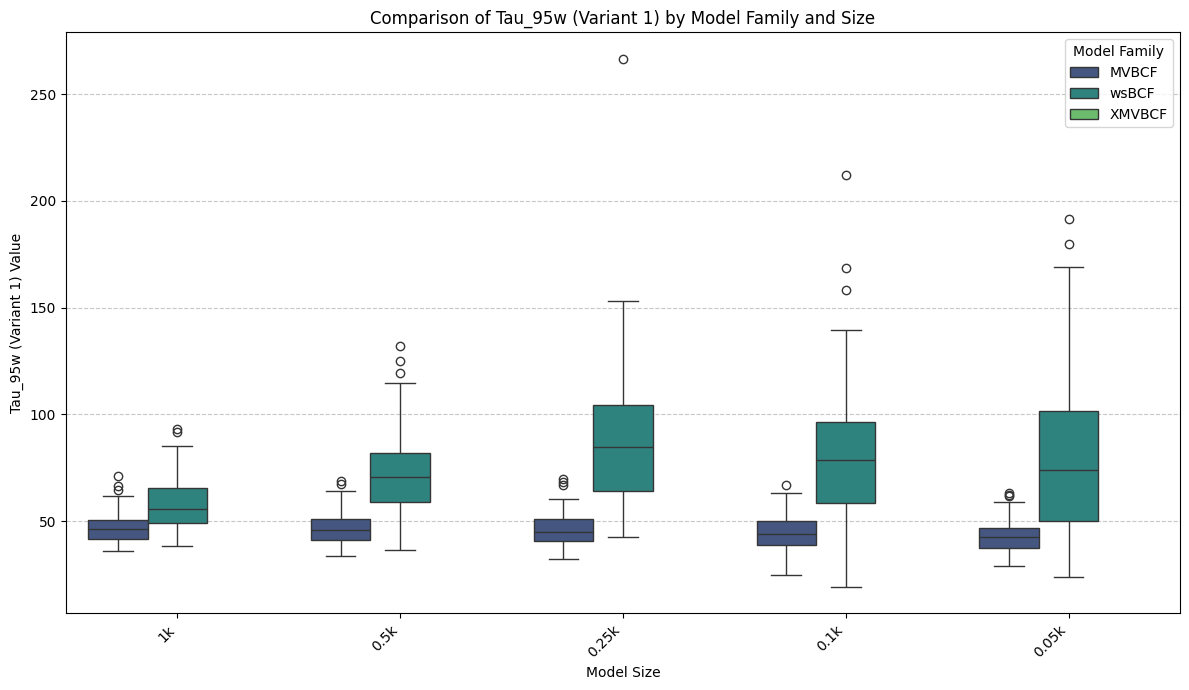

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF           XMVBCF             wsBCF
   1k 47.330 +/- 7.239 52.154 +/- 3.990 59.394 +/- 11.803
 0.5k 46.784 +/- 7.625 52.998 +/- 3.985 68.431 +/- 16.012
0.25k 47.076 +/- 8.002 52.802 +/- 4.174 89.534 +/- 26.939
 0.1k 44.810 +/- 7.205 53.084 +/- 4.163 84.414 +/- 30.682
0.05k 42.856 +/- 7.853 52.369 +/- 3.492 75.341 +/- 35.342




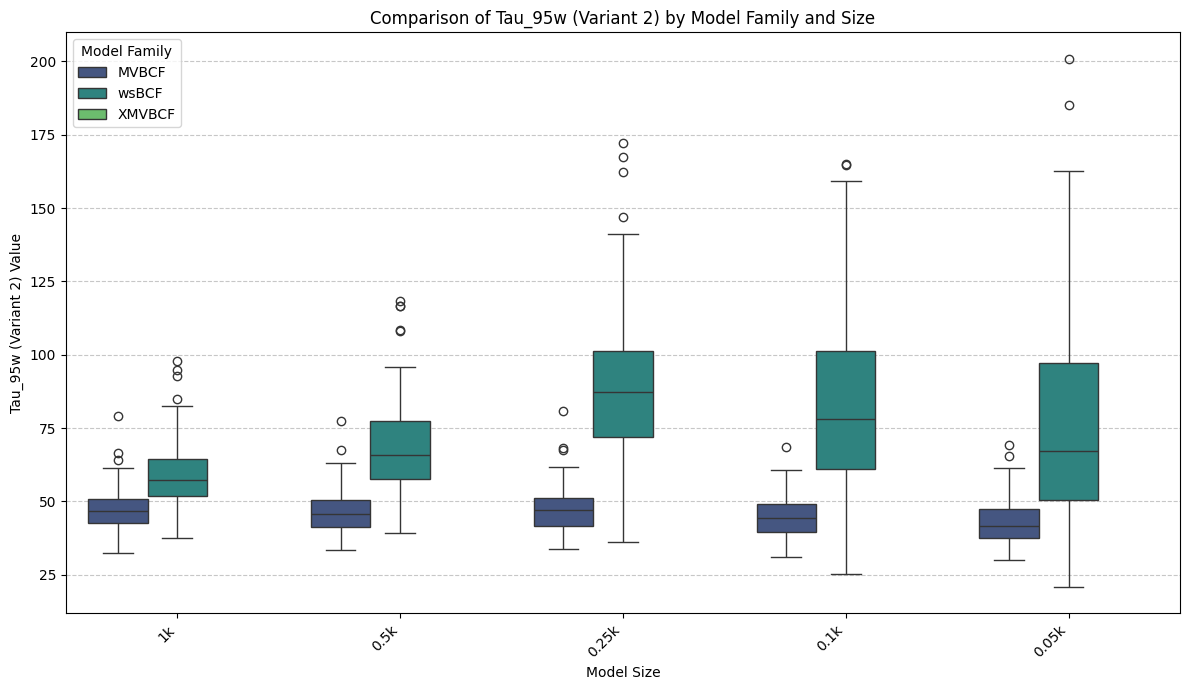

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("BCF_simulation_results_DGP1.csv")
    df_wsmvbcf = pd.read_csv("wsBCF_simulation_results_DGP1.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP1.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"bcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["BCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF           XMVBCF             wsBCF
   1k 37.739 +/- 5.242 37.064 +/- 5.414  38.370 +/- 5.392
 0.5k 37.692 +/- 5.239 37.049 +/- 5.295  39.014 +/- 6.676
0.25k 37.737 +/- 5.316 37.145 +/- 5.452  41.055 +/- 7.931
 0.1k 37.721 +/- 5.304 37.321 +/- 5.319 40.054 +/- 16.796
0.05k 37.584 +/- 5.341 37.001 +/- 5.333 39.625 +/- 18.299




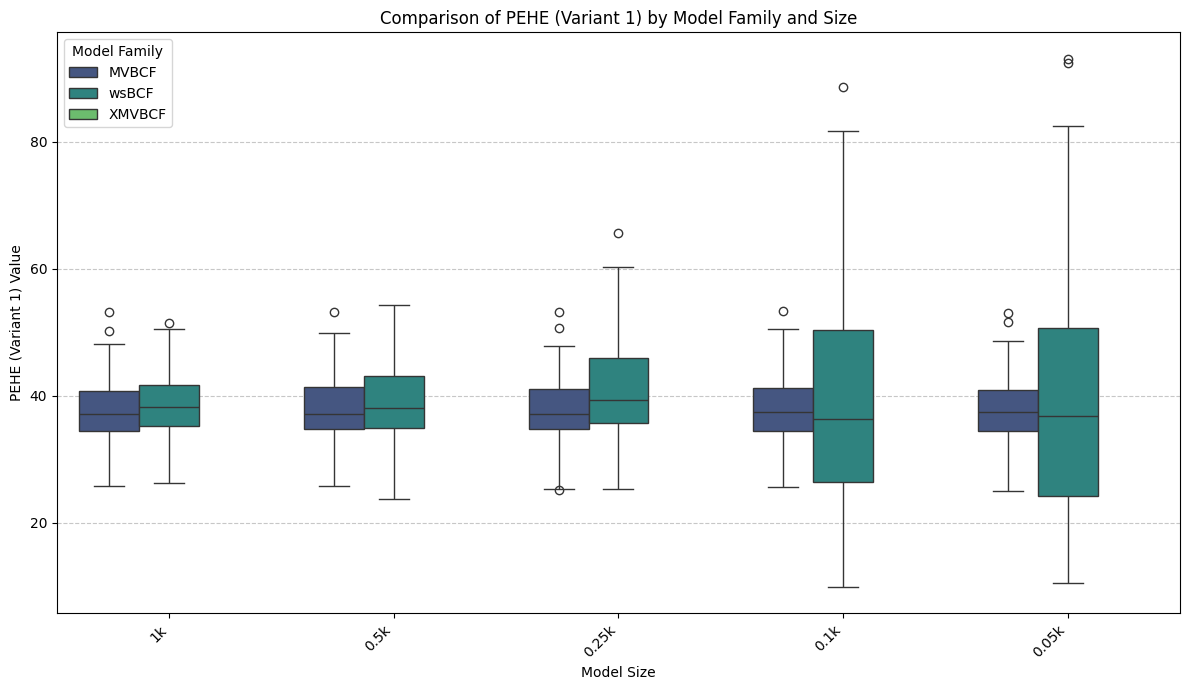

----- Comparison for PEHE (Variant 2) -----
Model              BCF          XMVBCF            wsBCF
   1k 10.029 +/- 2.123 9.911 +/- 1.963 10.214 +/- 2.308
 0.5k 10.154 +/- 2.196 9.821 +/- 2.076 10.464 +/- 2.693
0.25k 10.253 +/- 2.206 9.832 +/- 2.050 11.351 +/- 3.324
 0.1k 10.225 +/- 2.368 9.939 +/- 1.930 14.725 +/- 7.697
0.05k 10.293 +/- 2.164 9.792 +/- 1.919 16.203 +/- 9.889




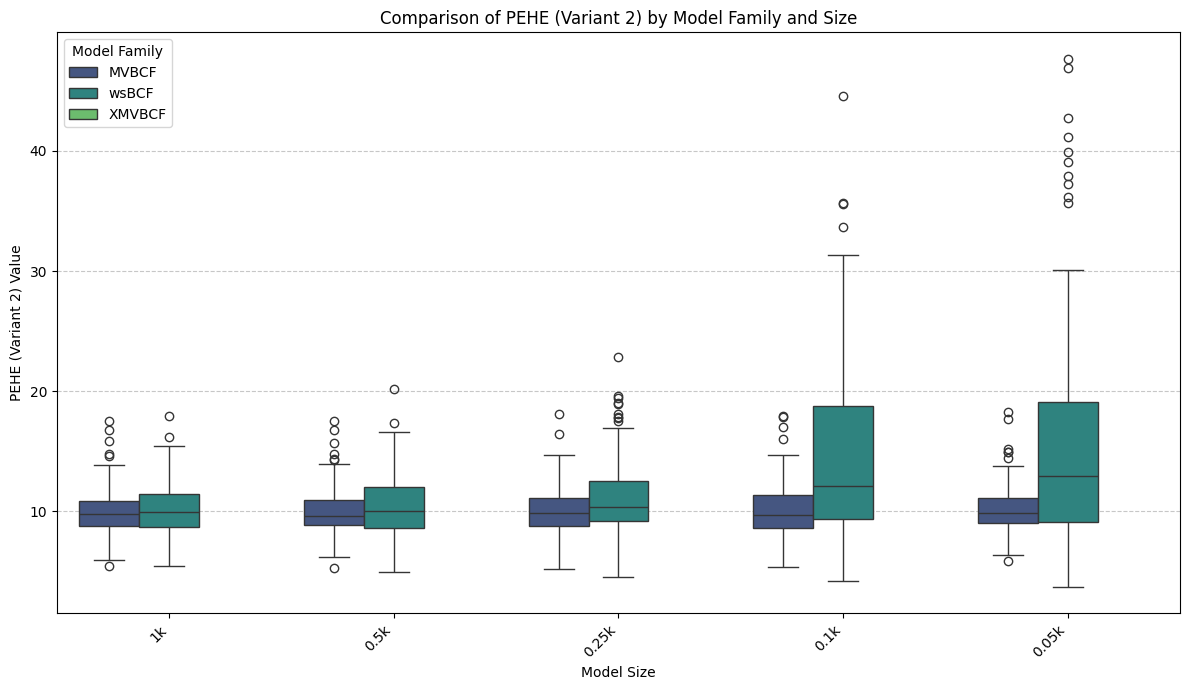

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.230 +/- 0.146 0.300 +/- 0.137 0.412 +/- 0.178
 0.5k 0.229 +/- 0.147 0.299 +/- 0.137 0.532 +/- 0.213
0.25k 0.227 +/- 0.144 0.294 +/- 0.131 0.643 +/- 0.194
 0.1k 0.190 +/- 0.135 0.300 +/- 0.129 0.659 +/- 0.253
0.05k 0.164 +/- 0.127 0.323 +/- 0.134 0.586 +/- 0.266




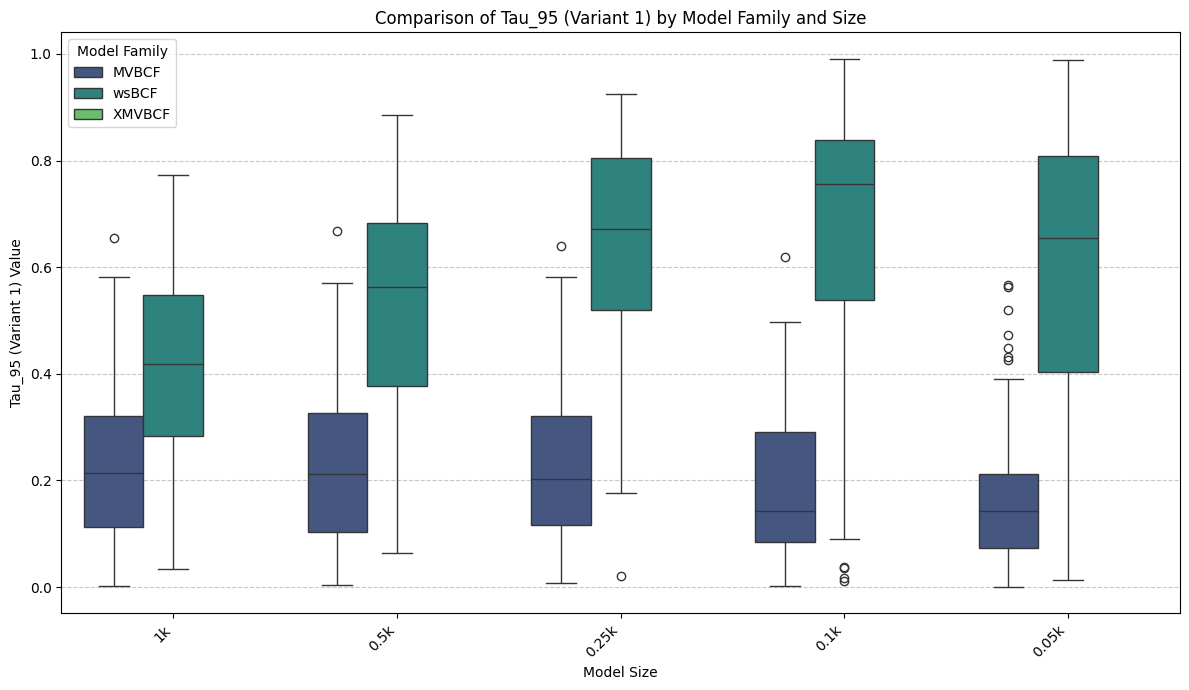

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.961 +/- 0.045 0.952 +/- 0.043 0.983 +/- 0.027
 0.5k 0.958 +/- 0.050 0.953 +/- 0.045 0.989 +/- 0.025
0.25k 0.949 +/- 0.053 0.953 +/- 0.042 0.992 +/- 0.021
 0.1k 0.940 +/- 0.060 0.952 +/- 0.041 0.960 +/- 0.099
0.05k 0.916 +/- 0.076 0.961 +/- 0.035 0.882 +/- 0.234




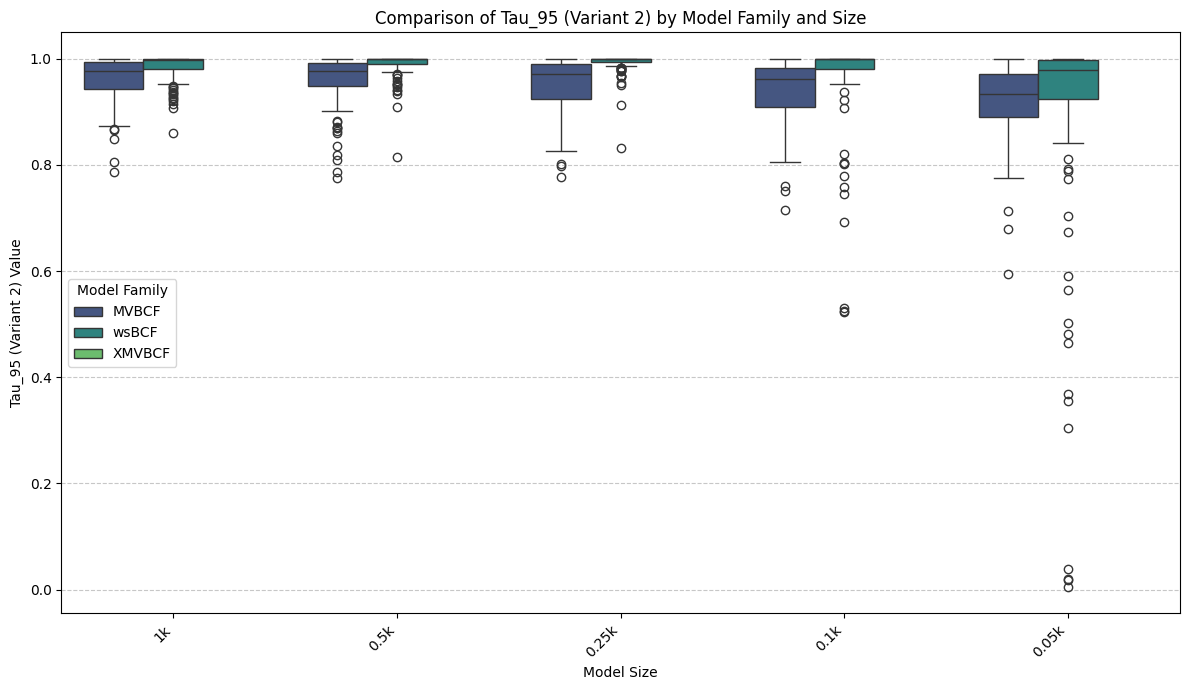

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF           XMVBCF              wsBCF
   1k 55.106 +/- 5.790 54.709 +/- 4.162  80.191 +/- 13.927
 0.5k 54.647 +/- 6.030 54.565 +/- 4.170  98.884 +/- 21.975
0.25k 54.508 +/- 5.747 54.809 +/- 3.998 121.186 +/- 30.049
 0.1k 51.344 +/- 5.868 55.158 +/- 4.556 116.297 +/- 32.560
0.05k 48.150 +/- 6.640 55.978 +/- 3.805 105.657 +/- 41.014




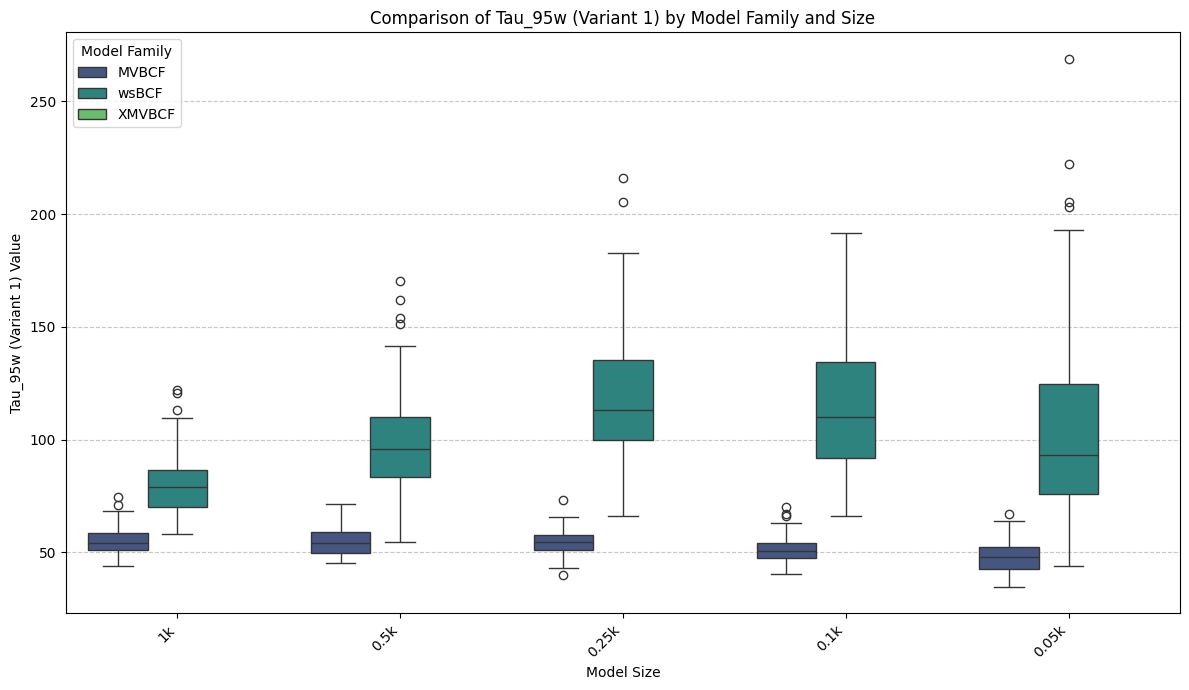

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF           XMVBCF             wsBCF
   1k 43.448 +/- 6.623 43.756 +/- 3.278  54.624 +/- 9.625
 0.5k 43.473 +/- 6.522 43.813 +/- 3.083 65.435 +/- 17.569
0.25k 42.744 +/- 6.459 43.622 +/- 3.092 76.868 +/- 21.743
 0.1k 41.485 +/- 6.558 43.518 +/- 3.237 78.685 +/- 31.133
0.05k 39.328 +/- 6.848 44.645 +/- 2.981 66.276 +/- 26.752




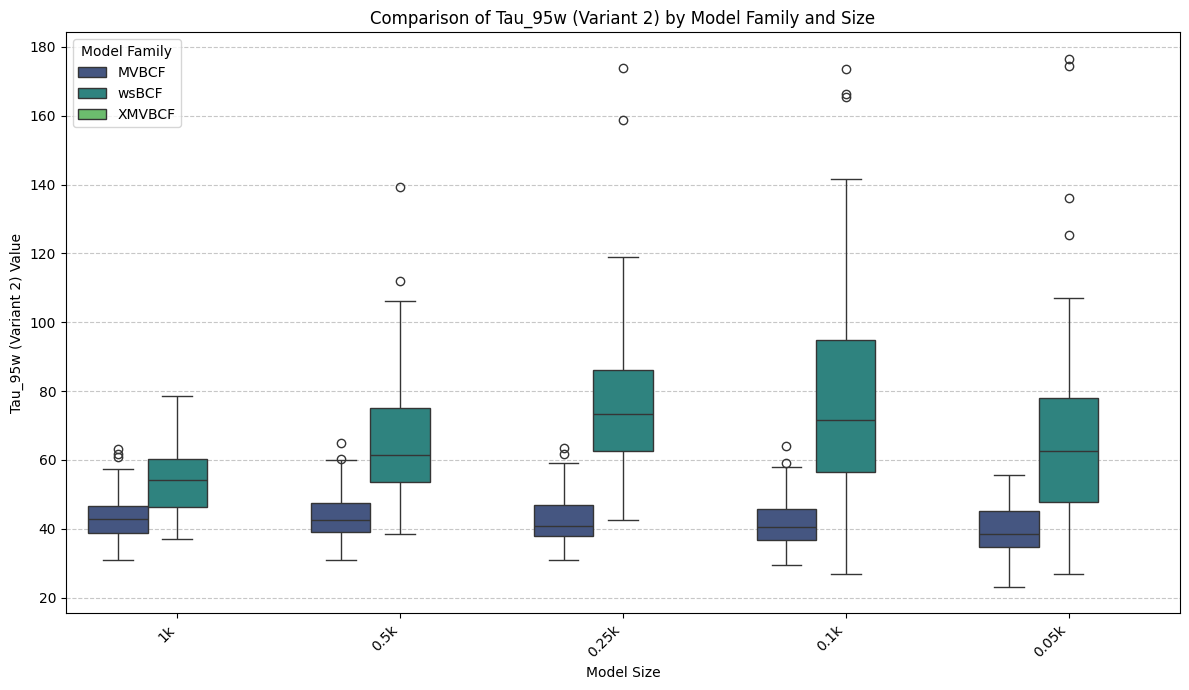

In [8]:
# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("BCF_simulation_results_DGP2.csv")
    df_wsmvbcf = pd.read_csv("wsBCF_simulation_results_DGP2.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP2.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"bcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["BCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF           XMVBCF             wsBCF
   1k 10.989 +/- 3.093 11.998 +/- 2.930  10.957 +/- 3.006
 0.5k 11.317 +/- 3.171 11.969 +/- 2.715  11.421 +/- 3.456
0.25k 11.092 +/- 3.199 11.724 +/- 3.118  12.757 +/- 4.784
 0.1k 11.437 +/- 3.269 12.091 +/- 2.985  18.202 +/- 9.666
0.05k 11.682 +/- 3.497 11.997 +/- 2.806 20.499 +/- 11.148




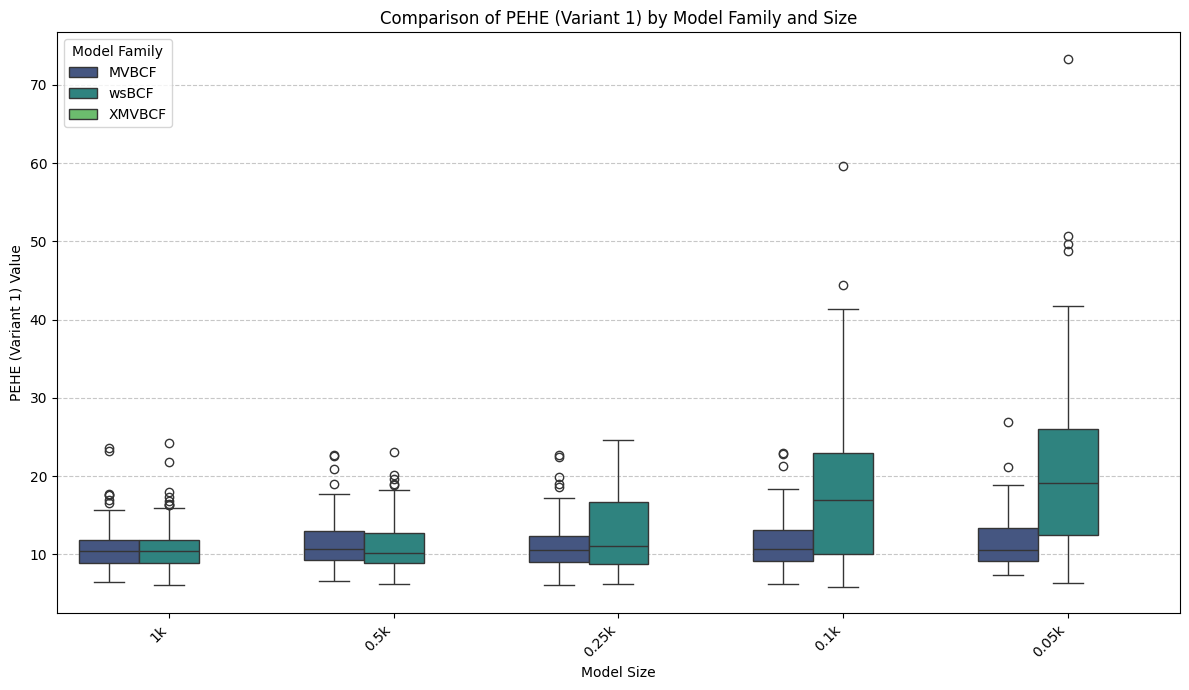

----- Comparison for PEHE (Variant 2) -----
Model              BCF           XMVBCF             wsBCF
   1k 10.476 +/- 2.735 10.760 +/- 2.647  10.758 +/- 2.834
 0.5k 10.511 +/- 2.821 10.670 +/- 2.460  11.363 +/- 3.201
0.25k 10.572 +/- 2.759 10.566 +/- 2.670  12.964 +/- 4.554
 0.1k 10.550 +/- 2.809 10.992 +/- 2.628  17.907 +/- 9.541
0.05k 10.760 +/- 3.015 10.854 +/- 2.726 17.731 +/- 10.636




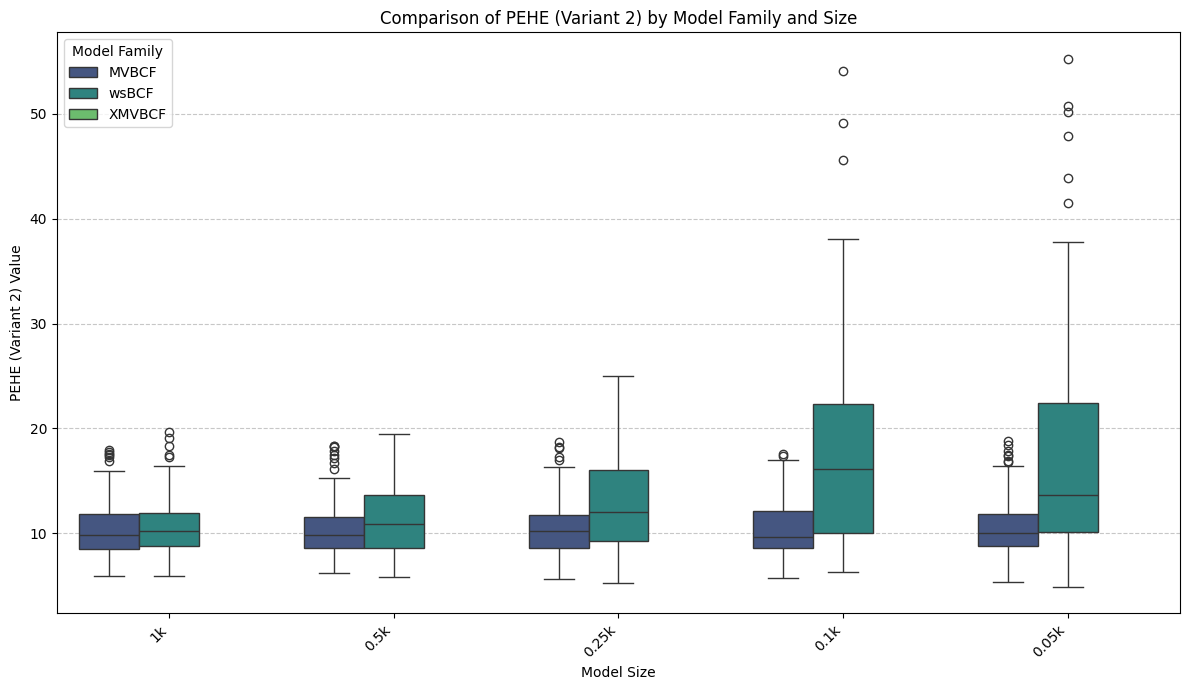

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.966 +/- 0.061 0.959 +/- 0.049 0.981 +/- 0.054
 0.5k 0.957 +/- 0.074 0.963 +/- 0.041 0.981 +/- 0.051
0.25k 0.949 +/- 0.089 0.964 +/- 0.053 0.985 +/- 0.047
 0.1k 0.937 +/- 0.086 0.956 +/- 0.050 0.914 +/- 0.206
0.05k 0.919 +/- 0.097 0.964 +/- 0.046 0.808 +/- 0.296




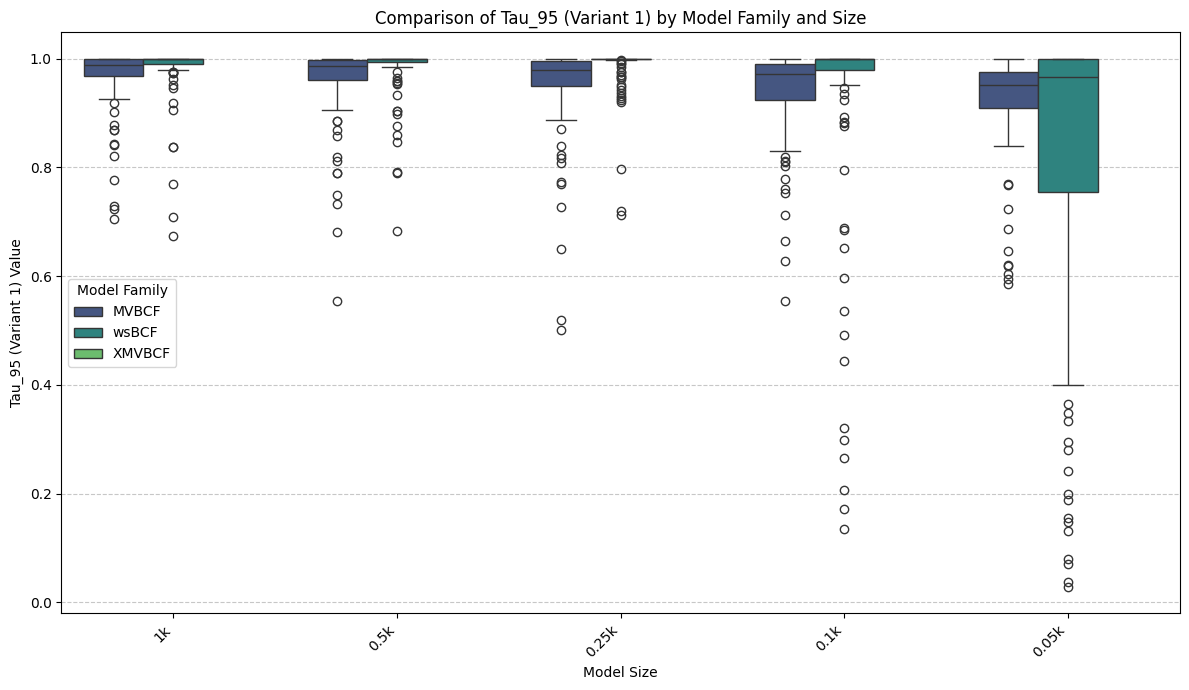

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF          XMVBCF           wsBCF
   1k 0.962 +/- 0.067 0.963 +/- 0.044 0.976 +/- 0.069
 0.5k 0.960 +/- 0.076 0.968 +/- 0.032 0.982 +/- 0.050
0.25k 0.956 +/- 0.071 0.968 +/- 0.039 0.985 +/- 0.057
 0.1k 0.942 +/- 0.087 0.961 +/- 0.046 0.938 +/- 0.155
0.05k 0.925 +/- 0.094 0.963 +/- 0.050 0.843 +/- 0.289




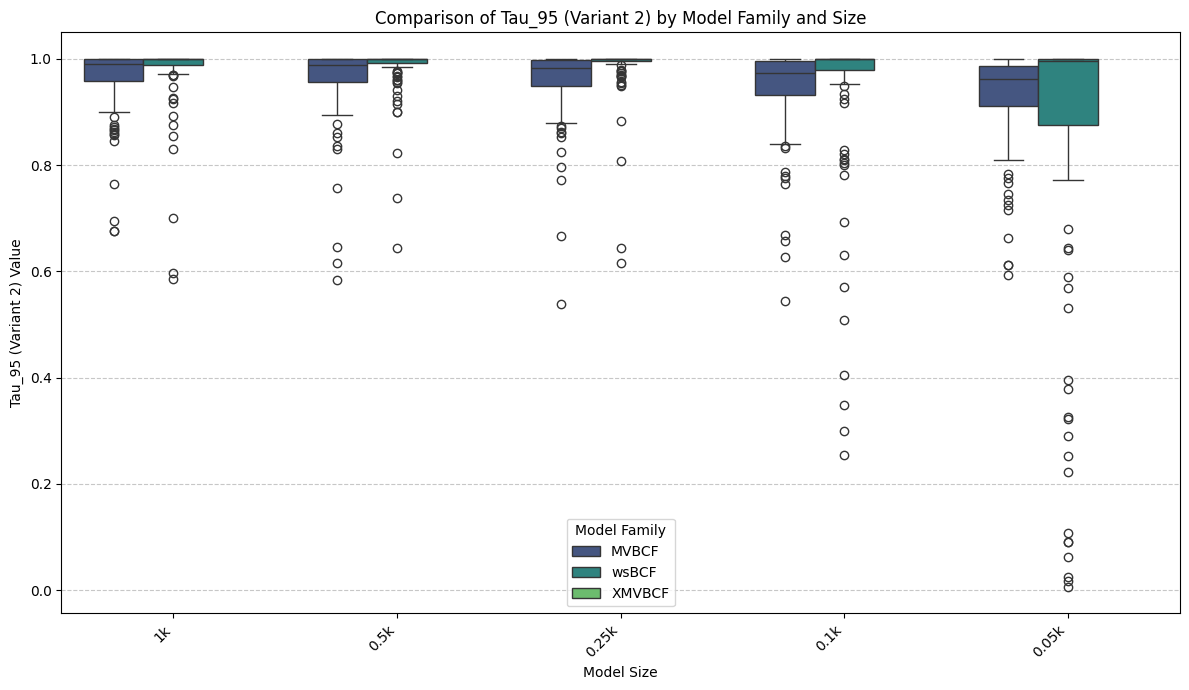

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF           XMVBCF             wsBCF
   1k 50.167 +/- 8.768 57.856 +/- 4.498 62.334 +/- 13.696
 0.5k 50.291 +/- 9.377 58.519 +/- 4.414 74.665 +/- 18.399
0.25k 48.688 +/- 9.360 58.514 +/- 4.801 91.345 +/- 28.975
 0.1k 47.472 +/- 9.696 57.509 +/- 4.531 99.427 +/- 48.713
0.05k 45.188 +/- 9.425 58.692 +/- 4.483 81.946 +/- 39.337




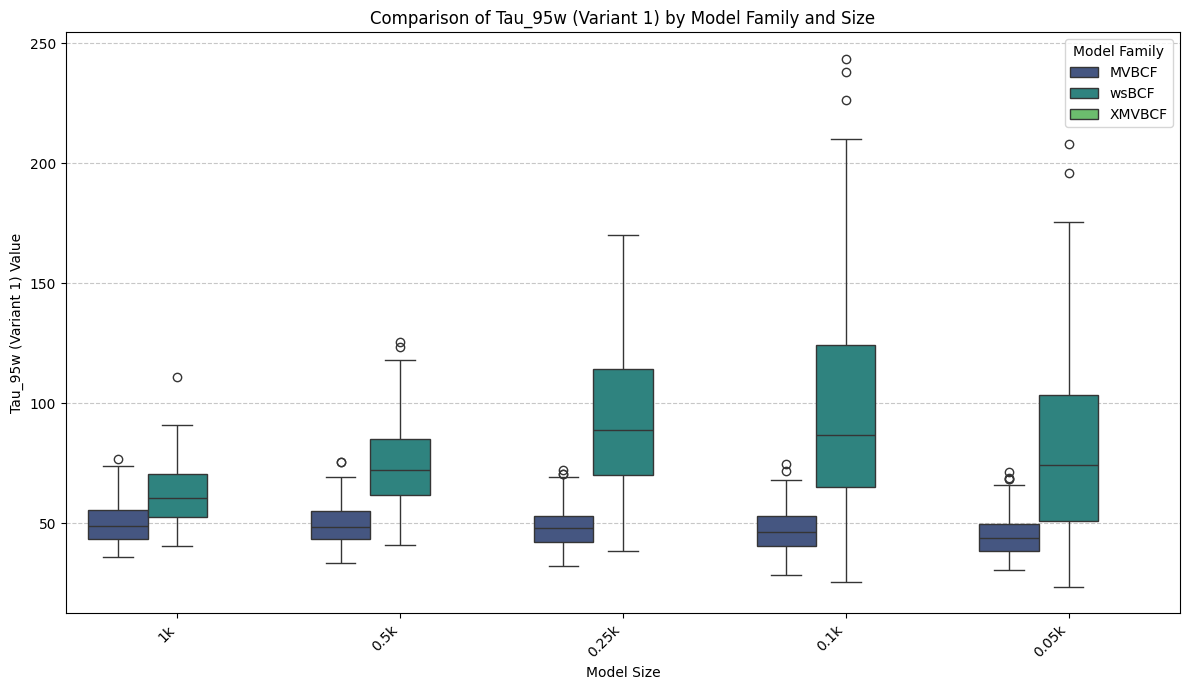

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF           XMVBCF             wsBCF
   1k 47.162 +/- 7.160 51.723 +/- 3.887 60.523 +/- 12.751
 0.5k 47.173 +/- 7.645 52.581 +/- 4.149 70.093 +/- 15.137
0.25k 46.800 +/- 7.337 52.717 +/- 3.891 88.758 +/- 23.612
 0.1k 44.747 +/- 7.333 52.165 +/- 4.217 85.889 +/- 32.095
0.05k 43.453 +/- 7.637 52.053 +/- 3.711 75.817 +/- 34.474




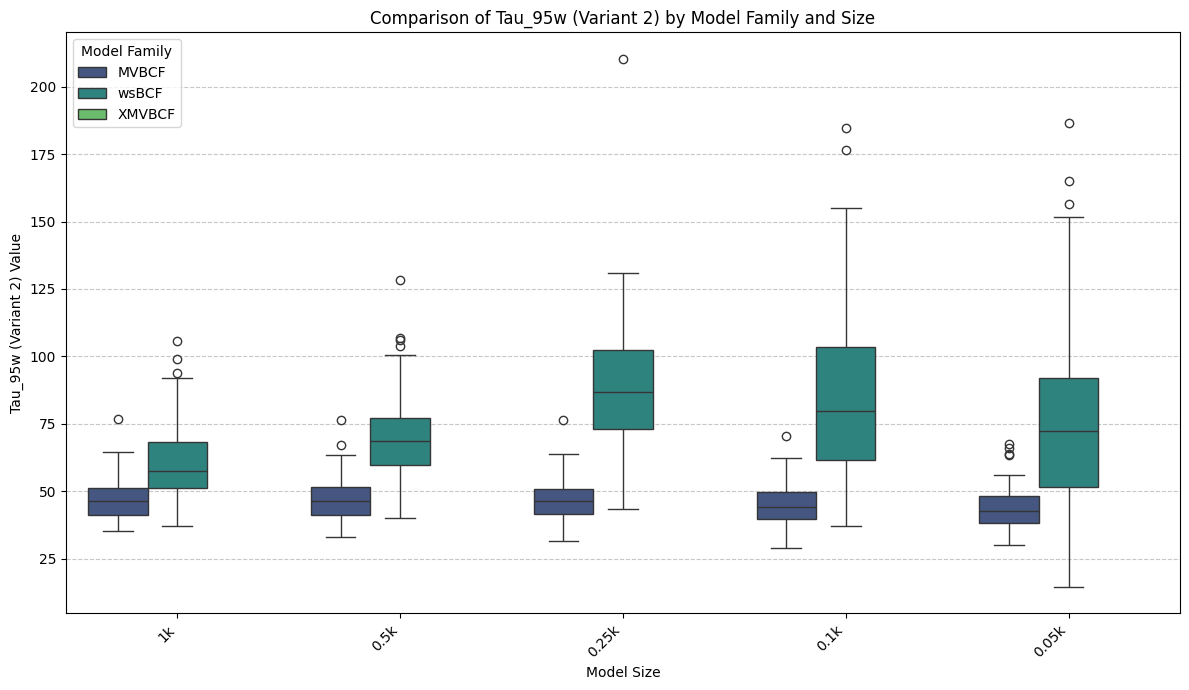

In [9]:
# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("BCF_simulation_results_DGP3.csv")
    df_wsmvbcf = pd.read_csv("wsBCF_simulation_results_DGP3.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP3.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"bcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["BCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()